In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from  load_data import load_images, load_labels
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from scipy.ndimage import rotate

import tensorflow as tf
from tensorflow import keras


After label smoothing: [0.1 0.1 0.1 0.1 0.1 0.9 0.1 0.1 0.1 0.1]
Train X shape: (60000, 28, 28)
Train y shape: (60000, 10)
Sample shape: (28, 28)


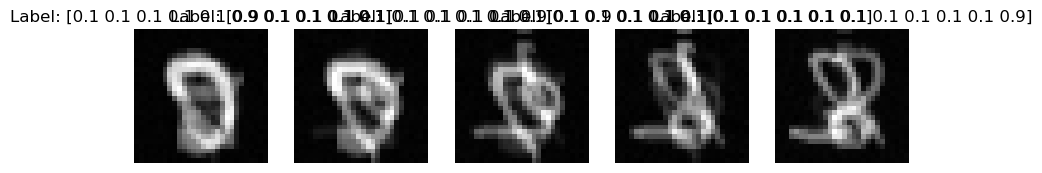

In [43]:
X_T = load_images("../MNIST_dataset/train-images-idx3-ubyte/train-images-idx3-ubyte")
y_T = load_labels("../MNIST_dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte")

#Label smoothing [0.1, 0.9] instead of [0, 1]
num_classes = 10
y_T = keras.utils.to_categorical(y_T, num_classes=num_classes)
y_T[y_T == 0] = 0.1
y_T[y_T == 1] = 0.9


print("After label smoothing:", y_T[0])

print("Train X shape:", X_T.shape)
print("Train y shape:", y_T.shape)
print("Sample shape:", X_T[0].shape)



# Scale
X_T = X_T / 255.0

#Scale the images in size by a random factor

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomZoom((-0.01, 0.01)),   # Reduce zoom range
    tf.keras.layers.RandomRotation(0.005),       # Keep small
    tf.keras.layers.RandomTranslation(0.005, 0.0005) # Reduce shift
])

X_T_aug = data_augmentation(X_T, training=True)

# Remove channel if needed
X_T = X_T_aug.numpy().squeeze()

# Generate some random noise to add to the images
noise = np.random.normal(loc=0.0, scale=0.005, size=X_T.shape)
# Add the noise to the images
X_T = X_T + noise

# Visualize some samples
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(X_T[i], cmap='gray')
    axes[i].set_title(f"Label: {y_T[i]}")
    axes[i].axis('off')
plt.show()

After label smoothing: [0.01 0.01 0.01 0.01 0.01 0.91 0.01 0.01 0.01 0.01]
Train X shape: (60000, 28, 28)
Train y shape: (60000, 10)
Sample shape: (28, 28)


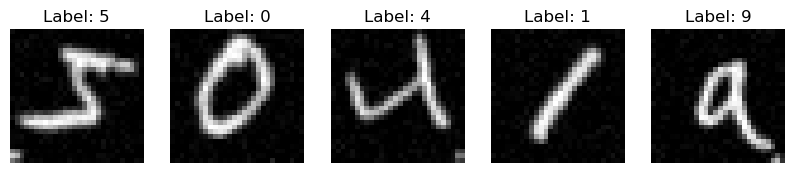

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8467 - loss: 0.9283
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9298 - loss: 0.7306
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9421 - loss: 0.6941
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9492 - loss: 0.6737
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9537 - loss: 0.6578
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9565 - loss: 0.6466
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9595 - loss: 0.6380
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9620 - loss: 0.6316
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9633 - loss: 0.6254
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9641 - loss: 0.6223
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9668 - loss: 0.6168
Epoch 12/15
1875/18

In [4]:
X_T = load_images("../MNIST_dataset/train-images-idx3-ubyte/train-images-idx3-ubyte")
y_T = load_labels("../MNIST_dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte")

num_classes = 10
label_smoothing = 0.1


y_T = keras.utils.to_categorical(y_T, num_classes=num_classes)

# Apply label smoothing properly
y_T = y_T * (1 - label_smoothing) + (label_smoothing / num_classes)

print("After label smoothing:", y_T[0])

X_T = X_T.astype("float32") / 255.0

print("Train X shape:", X_T.shape)
print("Train y shape:", y_T.shape)
print("Sample shape:", X_T[0].shape)

# Add channel dimension if missing (important for Keras)
if len(X_T.shape) == 3:
    X_T = np.expand_dims(X_T, -1)

# ---------------------------
# DATA AUGMENTATION (SAFE FOR MNIST)
# ---------------------------
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

# ---------------------------
# OPTIONAL: ADD VERY LIGHT NOISE
# ---------------------------
def add_noise(images):
    noise = np.random.normal(0.0, 0.03, images.shape)
    images = images + noise
    return np.clip(images, 0.0, 1.0)

# ---------------------------
# VISUALIZE AUGMENTED SAMPLES
# ---------------------------
augmented_samples = data_augmentation(X_T[:5], training=True)
augmented_samples = add_noise(augmented_samples.numpy())

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(augmented_samples[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {np.argmax(y_T[i])}")
    axes[i].axis('off')
plt.show()

# ---------------------------
# MODEL (EXAMPLE)
# ---------------------------
model = keras.Sequential([
    data_augmentation,  # 👈 applied only during training
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------
# TRAIN
# ---------------------------
model.fit(
    X_T,
    y_T,
    batch_size=32,   # 👈 increased from 8 (more stable)
    epochs=15,
    verbose=1
)

In [20]:
print("Train X shape:", X_T.shape)

Train X shape: (60000, 28, 28)


In [21]:
#reshape to (n_samples, n_features)
X_T = X_T.reshape(X_T.shape[0], -1)

# One-hot encode labels
y_train_encoded = y_T

In [22]:
# Tran and val split
X_train, X_val, y_train, y_val = train_test_split(X_T, y_train_encoded, test_size=(1/6), random_state=42)
print("After split:")
print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)
print("Val X shape:", X_val.shape)
print("Val y shape:", y_val.shape)

After split:
Train X shape: (50000, 784)
Train y shape: (50000, 10)
Val X shape: (10000, 784)
Val y shape: (10000, 10)


In [23]:
print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Input shape:    {X_train.shape[1]} features (28x28 pixels)")
print(f"Output shape:   {y_train.shape[1]} classes")

Training set:   50000 samples
Validation set: 10000 samples
Input shape:    784 features (28x28 pixels)
Output shape:   10 classes


In [24]:
# Create the model
learning_rates = [0.001]
hidden_layers = [(256, 128)]
batch_sizes = [32]

epochs = 15
verbose = 1

results = []
for lr in learning_rates:
    for hl in hidden_layers:
        for bs in batch_sizes:
            model = tf.keras.models.Sequential()
            model.add(tf.keras.layers.Input(shape=(784,)))
            for units in hl:
                model.add(tf.keras.layers.Dense(units, activation='relu'))
            model.add(tf.keras.layers.Dense(10, activation='softmax'))
            
            model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])
            
            history = model.fit(X_train, y_train,
                                batch_size=bs,
                                epochs=epochs,
                                validation_data=(X_val, y_val),
                                verbose=verbose)
            
            
            test_loss, test_accuracy = model.evaluate(X_val, y_val, verbose=0)
            results.append((lr, hl, bs, test_accuracy))
            print(f"LR: {lr}, Hidden: {hl}, Batch: {bs} => Test Accuracy: {test_accuracy:.4f}")

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1078 - loss: 7220.5601 - val_accuracy: 0.0981 - val_loss: 19677.5762
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0981 - loss: 42340.5234 - val_accuracy: 0.1010 - val_loss: 85376.4922
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0982 - loss: 93392.3906 - val_accuracy: 0.1060 - val_loss: 105457.5234
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1003 - loss: 143966.5000 - val_accuracy: 0.0980 - val_loss: 286514.0625
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0981 - loss: 217766.1875 - val_accuracy: 0.1010 - val_loss: 227660.4219
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1005 - loss: 282178.0000 - val_accuracy: 0.0984 - val_loss: 203526.0938
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1004 - loss: 354732.5312 - val_accuracy: 0.1000 - val_loss: 313033.0312
Epoch 8/15
1563/1563 ━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1060 - loss: 1370757.7500


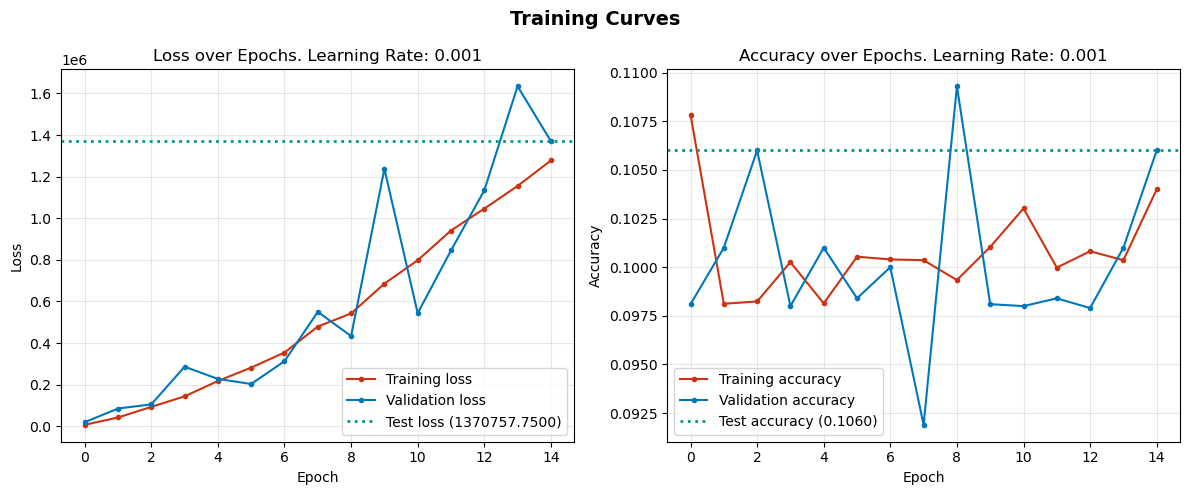

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Evaluate on test set for reference line
test_loss, test_accuracy = model.evaluate(X_val, y_val, verbose=verbose)

# Loss curves
axes[0].plot(range(epochs), history.history['loss'], 'o-', color='#CC3311', markersize=3, label='Training loss')
axes[0].plot(range(epochs), history.history['val_loss'], 'o-', color='#0077BB', markersize=3, label='Validation loss')
axes[0].axhline(y=test_loss, color='#009988', linestyle=':', linewidth=2, label=f'Test loss ({test_loss:.4f})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'Loss over Epochs. Learning Rate: {lr}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(range(epochs), history.history['accuracy'], 'o-', color='#CC3311', markersize=3, label='Training accuracy')
axes[1].plot(range(epochs), history.history['val_accuracy'], 'o-', color='#0077BB', markersize=3, label='Validation accuracy')
axes[1].axhline(y=test_accuracy, color='#009988', linestyle=':', linewidth=2, label=f'Test accuracy ({test_accuracy:.4f})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'Accuracy over Epochs. Learning Rate: {lr}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Print 10 best results
results.sort(key=lambda x: x[3], reverse=True)
for i in range(10):
    lr, hl, bs, acc = results[i]
    print(f"Rank {i+1}: LR={lr}, Hidden={hl}, Batch={bs} => Test Accuracy: {acc:.4f}")



Rank 1: LR=0.001, Hidden=(256, 128), Batch=32 => Test Accuracy: 0.1060


IndexError: list index out of range

In [27]:
# Implement teperature scaling for the model's output probabilities
class TemperatureScaling(tf.keras.layers.Layer):
    def __init__(self, temperature=1.0):
        super(TemperatureScaling, self).__init__()
        self.temperature = temperature

    def call(self, logits):
        return tf.nn.softmax(logits / self.temperature)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


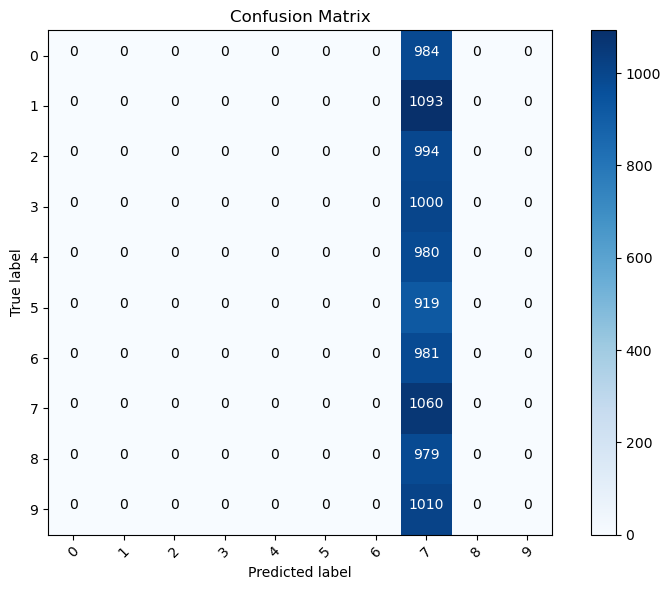

In [28]:
# Plot the confusion matrix
def plot_confusion_matrix(cm, classes, title="Confusion matrix", cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = "d"
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
plot_confusion_matrix(cm, classes=[str(i) for i in range(10)], title="Confusion Matrix")
plt.show()

In [29]:
# Load test data
X_test = load_images("../MNIST_dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte")
y_test = load_labels("../MNIST_dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte")

# Preprocess test data
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0
y_test_encoded = keras.utils.to_categorical(y_test, num_classes=10)
y_test_encoded[y_test_encoded == 0] = 0.1
y_test_encoded[y_test_encoded == 1] = 0.9
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Final Test Accuracy on unseen test set: {test_accuracy:.4f}")

Final Test Accuracy on unseen test set: 0.1028


In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705,440 (2.69 MB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 470,294 (1.79 MB)

In [5]:
model.save("mnist_model_modified2_data.keras")